# Census: Clasificación Multiclase Multivariable con PyTorch

Este notebook entrena una red neuronal en PyTorch para **clasificación multiclase** usando todas las variables del dataset `adult.csv` (excepto la variable objetivo).

Objetivo elegido: `occupation` (múltiples clases).

Métricas calculadas: `accuracy`, `precision`, `recall`, `f1` (macro y weighted), matriz de confusión y `roc_auc_ovr_macro`.

In [13]:
# Si falta PyTorch en tu entorno, descomenta la siguiente línea:
# %pip install torch

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [14]:
# 1) Cargar, limpiar y definir target multiclase
df = pd.read_csv('adult.csv').copy()
df.columns = [c.strip() for c in df.columns]

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# '?' representa valor faltante
df = df.replace('?', np.nan)

target_col = 'occupation'
if target_col not in df.columns:
    raise ValueError('No se encontró la columna target occupation en adult.csv')

# Para clasificación multiclase removemos filas sin etiqueta target
df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
y_raw = df[target_col].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
num_classes = len(class_names)

print('Shape total X:', X.shape)
print('Número de clases:', num_classes)
print('Clases:', list(class_names))

Shape total X: (30718, 14)
Número de clases: 14
Clases: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']


C:\Users\jorge\AppData\Local\Temp\ipykernel_18460\2189552444.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [15]:
# 2) Split + preprocesamiento multivariable (num + cat)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ]
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
if hasattr(X_val_t, 'toarray'):
    X_val_t = X_val_t.toarray()
if hasattr(X_test_t, 'toarray'):
    X_test_t = X_test_t.toarray()

X_train_t = X_train_t.astype(np.float32)
X_val_t = X_val_t.astype(np.float32)
X_test_t = X_test_t.astype(np.float32)

y_train_np = y_train.astype(np.int64)
y_val_np = y_val.astype(np.int64)
y_test_np = y_test.astype(np.int64)

print('X_train transformado:', X_train_t.shape)
print('X_val transformado:', X_val_t.shape)
print('X_test transformado:', X_test_t.shape)

C:\Users\jorge\AppData\Local\Temp\ipykernel_18460\2743590202.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


X_train transformado: (19659, 91)
X_val transformado: (4915, 91)
X_test transformado: (6144, 91)


In [16]:
# 3) Definir red multiclase y DataLoaders
from torch.utils.data import WeightedRandomSampler

train_ds = TensorDataset(
    torch.from_numpy(X_train_t),
    torch.from_numpy(y_train_np)
 )
val_ds = TensorDataset(
    torch.from_numpy(X_val_t),
    torch.from_numpy(y_val_np)
 )
test_ds = TensorDataset(
    torch.from_numpy(X_test_t),
    torch.from_numpy(y_test_np)
 )

class_counts = np.bincount(y_train_np, minlength=num_classes)
sample_weights = 1.0 / np.maximum(class_counts[y_train_np], 1)
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=256, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

input_dim = X_train_t.shape[1]

class CensusMLP(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model = CensusMLP(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('input_dim:', input_dim)
print('num_classes:', num_classes)

input_dim: 91
num_classes: 14


Epoch 01/40 | train_loss=2.2651 | val_loss=2.1921 | val_f1_macro=0.1857 | lr=3.00e-04
Epoch 02/40 | train_loss=1.8961 | val_loss=2.0816 | val_f1_macro=0.2030 | lr=3.00e-04
Epoch 03/40 | train_loss=1.8341 | val_loss=2.0570 | val_f1_macro=0.2046 | lr=3.00e-04
Epoch 04/40 | train_loss=1.8095 | val_loss=2.0434 | val_f1_macro=0.2109 | lr=3.00e-04
Epoch 05/40 | train_loss=1.7786 | val_loss=2.0406 | val_f1_macro=0.2101 | lr=3.00e-04
Epoch 06/40 | train_loss=1.7556 | val_loss=2.0204 | val_f1_macro=0.2211 | lr=3.00e-04
Epoch 07/40 | train_loss=1.7548 | val_loss=2.0255 | val_f1_macro=0.2211 | lr=3.00e-04
Epoch 08/40 | train_loss=1.7361 | val_loss=2.0325 | val_f1_macro=0.2173 | lr=3.00e-04
Epoch 09/40 | train_loss=1.7242 | val_loss=2.0126 | val_f1_macro=0.2196 | lr=3.00e-04
Epoch 10/40 | train_loss=1.7061 | val_loss=2.0129 | val_f1_macro=0.2225 | lr=3.00e-04
Epoch 11/40 | train_loss=1.6877 | val_loss=2.0165 | val_f1_macro=0.2228 | lr=3.00e-04
Epoch 12/40 | train_loss=1.6979 | val_loss=2.0014 | va

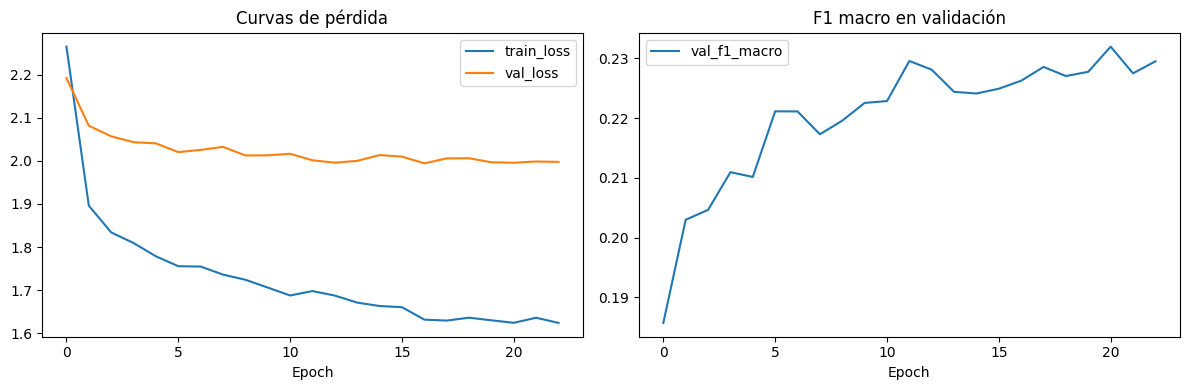

In [17]:
# 4) Entrenamiento completo
from copy import deepcopy

EPOCHS = 40
patience = 6
best_val_loss = float('inf')
best_state = None
epochs_without_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    all_val_preds = []
    all_val_true = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            preds = torch.argmax(logits, dim=1)
            val_losses.append(loss.item())
            all_val_preds.extend(preds.detach().cpu().numpy().tolist())
            all_val_true.extend(yb.detach().cpu().numpy().tolist())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    val_f1_macro = f1_score(all_val_true, all_val_preds, average='macro')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1_macro'].append(val_f1_macro)

    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1_macro={val_f1_macro:.4f} | lr={current_lr:.2e}')

    if epochs_without_improve >= patience:
        print(f'Early stopping activado en epoch {epoch:02d}.')
        break

if best_state is not None:
    model.load_state_dict(best_state)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.title('Curvas de pérdida')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['val_f1_macro'], label='val_f1_macro')
plt.title('F1 macro en validación')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# 5) Preparar predicciones para evaluar métricas (multiclase)
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test_t).to(device)
    logits = model(X_test_tensor)
    y_proba = torch.softmax(logits, dim=1).cpu().numpy()

y_pred = np.argmax(y_proba, axis=1)
y_true = y_test_np

print('Predicciones listas para métricas.')
print('Shape y_true:', y_true.shape, '| Shape y_pred:', y_pred.shape, '| Shape y_proba:', y_proba.shape)

Predicciones listas para métricas.
Shape y_true: (6144,) | Shape y_pred: (6144,) | Shape y_proba: (6144, 14)


### Accuracy

In [19]:
def accuracy_multiclass(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

acc = accuracy_multiclass(y_true, y_pred)
print(f'Accuracy: {acc:.4f}')

Accuracy: 0.2907


### Precision y Recall

In [20]:
def precision_multiclass(y_true, y_pred, average='macro'):
    return precision_score(y_true, y_pred, average=average, zero_division=0)

def recall_multiclass(y_true, y_pred, average='macro'):
    return recall_score(y_true, y_pred, average=average, zero_division=0)

p_macro = precision_multiclass(y_true, y_pred, average='macro')
r_macro = recall_multiclass(y_true, y_pred, average='macro')
p_weighted = precision_multiclass(y_true, y_pred, average='weighted')
r_weighted = recall_multiclass(y_true, y_pred, average='weighted')

print(f'Precision macro: {p_macro:.4f} | Recall macro: {r_macro:.4f}')
print(f'Precision weighted: {p_weighted:.4f} | Recall weighted: {r_weighted:.4f}')

Precision macro: 0.2506 | Recall macro: 0.3180
Precision weighted: 0.3369 | Recall weighted: 0.2907


### Matriz de Confusión

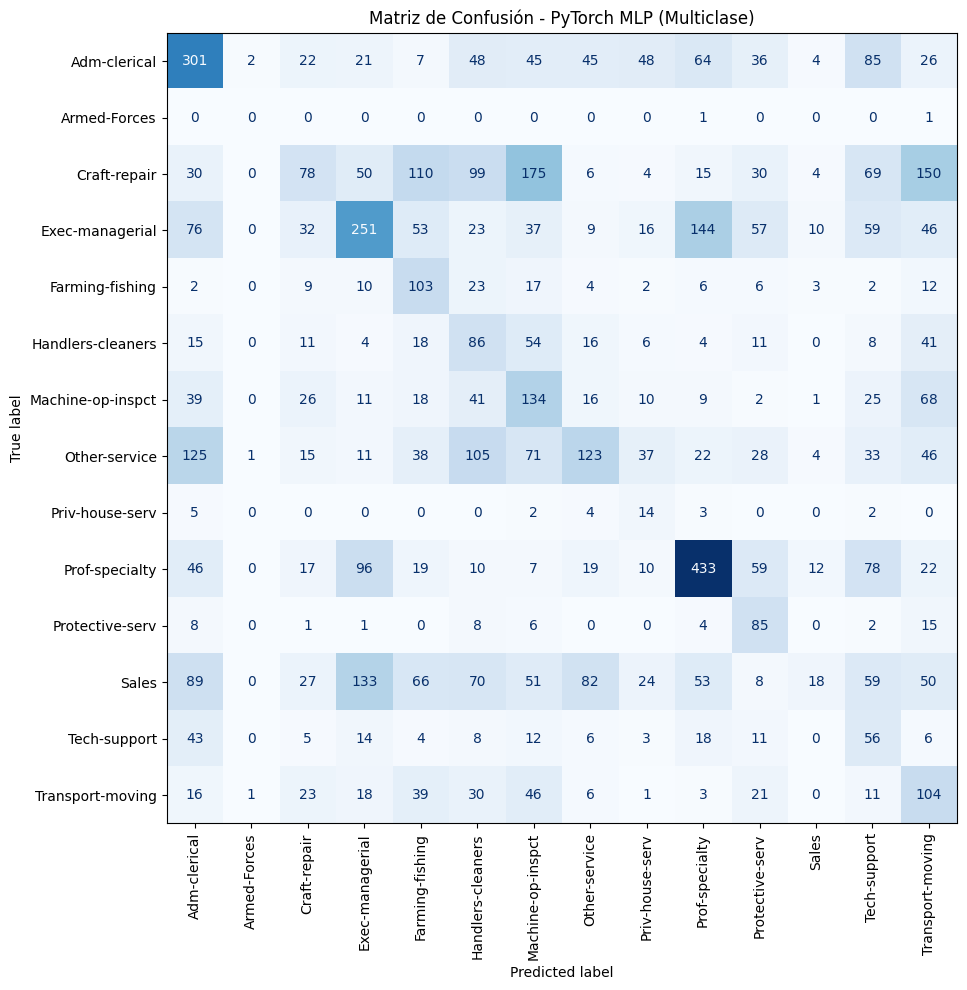

In [21]:
def confusion_matrix_multiclass(y_true, y_pred):
    return confusion_matrix(y_true, y_pred)

cm = confusion_matrix_multiclass(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax, colorbar=False)
plt.title('Matriz de Confusión - PyTorch MLP (Multiclase)')
plt.tight_layout()
plt.show()

### ROC-AUC (One-vs-Rest)

In [22]:
def roc_auc_ovr_macro(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        return np.nan

auc_ovr_macro = roc_auc_ovr_macro(y_true, y_proba)
print(f'ROC-AUC OVR macro: {auc_ovr_macro:.4f}')

print('\nReporte de clasificación:\n')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

ROC-AUC OVR macro: 0.7905

Reporte de clasificación:

                   precision    recall  f1-score   support

     Adm-clerical     0.3786    0.3992    0.3886       754
     Armed-Forces     0.0000    0.0000    0.0000         2
     Craft-repair     0.2932    0.0951    0.1436       820
  Exec-managerial     0.4048    0.3087    0.3503       813
  Farming-fishing     0.2168    0.5176    0.3056       199
Handlers-cleaners     0.1561    0.3139    0.2085       274
Machine-op-inspct     0.2040    0.3350    0.2535       400
    Other-service     0.3661    0.1866    0.2472       659
  Priv-house-serv     0.0800    0.4667    0.1366        30
   Prof-specialty     0.5558    0.5229    0.5389       828
  Protective-serv     0.2401    0.6538    0.3512       130
            Sales     0.3214    0.0247    0.0458       730
     Tech-support     0.1145    0.3011    0.1659       186
 Transport-moving     0.1772    0.3260    0.2296       319

         accuracy                         0.2907      6144


### F1-Score

In [23]:
def f1_multiclass(y_true, y_pred, average='macro'):
    return f1_score(y_true, y_pred, average=average, zero_division=0)

f1_macro = f1_multiclass(y_true, y_pred, average='macro')
f1_weighted = f1_multiclass(y_true, y_pred, average='weighted')

print(f'F1 macro: {f1_macro:.4f}')
print(f'F1 weighted: {f1_weighted:.4f}')

F1 macro: 0.2404
F1 weighted: 0.2786


### Top clases por F1

In [24]:
# 6) Top clases con mayor F1 (resumen rápido)
from sklearn.metrics import f1_score

f1_por_clase = f1_score(y_true, y_pred, average=None, zero_division=0)
df_f1_clase = pd.DataFrame({
    'clase': class_names,
    'f1': f1_por_clase
}).sort_values('f1', ascending=False)

print('Top 10 clases por F1:')
print(df_f1_clase.head(10))

print('\nBottom 10 clases por F1:')
print(df_f1_clase.tail(10))

Top 10 clases por F1:
                clase        f1
9      Prof-specialty  0.538892
0        Adm-clerical  0.388638
10    Protective-serv  0.351240
3     Exec-managerial  0.350314
4     Farming-fishing  0.305638
6   Machine-op-inspct  0.253548
7       Other-service  0.247236
13   Transport-moving  0.229581
5   Handlers-cleaners  0.208485
12       Tech-support  0.165926

Bottom 10 clases por F1:
                clase        f1
4     Farming-fishing  0.305638
6   Machine-op-inspct  0.253548
7       Other-service  0.247236
13   Transport-moving  0.229581
5   Handlers-cleaners  0.208485
12       Tech-support  0.165926
2        Craft-repair  0.143646
8     Priv-house-serv  0.136585
11              Sales  0.045802
1        Armed-Forces  0.000000
